<a href="https://colab.research.google.com/github/boba-ueh/ueh_investments1/blob/main/final_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# download the R environment file, where you could change the environment file you build in the previous steps
R_environment_file <- "https://drive.google.com/file/d/1MPTuv_c3-_imaM3FqiQePFoTwZrrAlot/view?usp=sharing"
download.file(R_environment_file,
      destfile="./library.tar.gz")

# unzip the compressed R library file: 'library.tar.gz' into the R library folder
untar("library.tar.gz", exdir = "library")

# change the R library directory into './library'
.libPaths("library")

Warning message in untar("library.tar.gz", exdir = "library"):
“‘/bin/tar -xf 'library.tar.gz' -C 'library'’ returned error code 2”


In [2]:
install.packages(c("quantmod", "xts", "PerformanceAnalytics", "tseries"))

# --- 0. KHAI BÁO THƯ VIỆN ---
library(googlesheets4)
library(dplyr)
library(ggplot2)
#library(psych)
library(quantmod)
library(xts)
library(PerformanceAnalytics)
library(tseries)
#library(readcsv)

gs4_deauth()
data <- read_sheet(
  "https://docs.google.com/spreadsheets/d/1_4NP-peyr8Eso2EaYF4bdgxVfXL2IzkjyglwT0ya5OA/edit?usp=sharing",
  sheet = 1
)
#head(data)

# Convert time column into Date format
data$time <- as.Date(data$time)

# --- CONVERT WHOLE TABLE TO XTS ---
stock_xts <- xts(
  data[, -1],          # remove time column
  order.by = data$time
)
symbols <- c("TRC", "GVR", "MBB", "SSI", "FPT", "VNINDEX")
for(sym in symbols){
  temp <- stock_xts[, paste0(sym, c(".open", ".high", ".low", ".close"))]
  colnames(temp) <- c("Open", "High", "Low", "Close")
  assign(sym, temp)
}

head(data)

Installing packages into ‘/content/library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘TTR’, ‘quadprog’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats

time,TRC.open,TRC.high,TRC.low,TRC.close,TRC.volume,GVR.open,GVR.high,GVR.low,GVR.close,⋯,FPT.open,FPT.high,FPT.low,FPT.close,FPT.volume,VNINDEX.open,VNINDEX.high,VNINDEX.low,VNINDEX.close,VNINDEX.volume
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2018-03-21,18.92,18.92,18.69,18.79,64780,12.97,12.97,8.47,9.42,⋯,16.04,16.17,15.96,15.96,999470,1.17,1.17,1.16,1.17,212812970
2018-03-22,18.79,19.05,18.79,18.99,11120,9.51,9.77,8.82,9.42,⋯,15.96,16.07,15.73,15.73,1264760,1.18,1.18,1.17,1.17,215497530
2018-03-23,18.43,18.85,18.43,18.85,3670,9.16,9.16,8.65,9.08,⋯,15.44,15.60,15.18,15.34,2833670,1.15,1.16,1.14,1.15,237107530
2018-03-26,18.59,18.66,18.49,18.66,3590,8.82,9.08,8.82,8.90,⋯,15.34,15.54,15.34,15.49,940840,1.15,1.18,1.15,1.17,175879690
2018-03-27,18.66,18.72,17.44,17.44,38950,9.34,9.51,9.08,9.42,⋯,15.68,15.73,15.44,15.57,993260,1.19,1.19,1.17,1.17,201305790
2018-03-28,18.07,18.46,18.07,18.46,68710,9.42,10.20,9.34,9.94,⋯,15.46,15.54,15.39,15.41,660440,1.17,1.18,1.17,1.17,165131520


#  2/ Technical Analysis — TRC

In [5]:
trc_return <- na.omit(diff(log(Cl(TRC))))

png("technical_analysis.png",
    width = 4000,
    height = 2500,
    res = 400)

chartSeries(last(TRC, "6 months"), theme = chartTheme("white"))

addSMA(n = 5, col = "blue")
addSMA(n = 20, col = "red")

addMACD()
addBBands()
addRSI()

dev.off()

agg_record_54378b75d1b 
                     2

===== stats_table=====


,Mean,SD,Variance,Skewness,Excess_Kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TRC,0.0008387757,0.01797238,0.0003230063,-0.21627673,3.240219
FPT,0.0007162905,0.02330402,0.0005430774,-0.09487858,1.427743
GVR,0.0006747101,0.03058034,0.0009351573,-0.11641775,1.356843
MBB,0.0006308073,0.02086612,0.0004353948,-0.91792341,7.889562
SSI,0.0004365056,0.02652938,0.0007038079,-0.30427919,2.599056


===== ER_vector=====
         TRC          FPT          GVR          MBB          SSI 
0.0008387757 0.0007162905 0.0006747101 0.0006308073 0.0004365056 
===== Sigma=====
             TRC          FPT          GVR          MBB          SSI
TRC 3.230063e-04 9.390038e-05 0.0002095925 0.0002051590 0.0002440949
FPT 9.390038e-05 5.430774e-04 0.0002014638 0.0001265309 0.0001334870
GVR 2.095925e-04 2.014638e-04 0.0009351573 0.0002758632 0.0003891861
MBB 2.051590e-04 1.265309e-04 0.0002758632 0.0004353948 0.0003688602
SSI 2.440949e-04 1.334870e-04 0.0003891861 0.0003688602 0.0007038079
===== Corr_mat=====
          TRC       FPT       GVR       MBB       SSI
TRC 1.0000000 0.2241976 0.3813536 0.5470708 0.5119483
FPT 0.2241976 1.0000000 0.2826987 0.2602100 0.2159141
GVR 0.3813536 0.2826987 1.0000000 0.4323245 0.4797201
MBB 0.5470708 0.2602100 0.4323245 1.0000000 0.6663357
SSI 0.5119483 0.2159141 0.4797201 0.6663357 1.0000000
===== Tìm tỷ trọng đầu tư để có Minimum Variance Portfolio (MVP) =====


[1] 0.6614392

[1] 0.3385608

===== ERP5 SDP5=====
[1] 0.0006594178
[1] 0.01724728


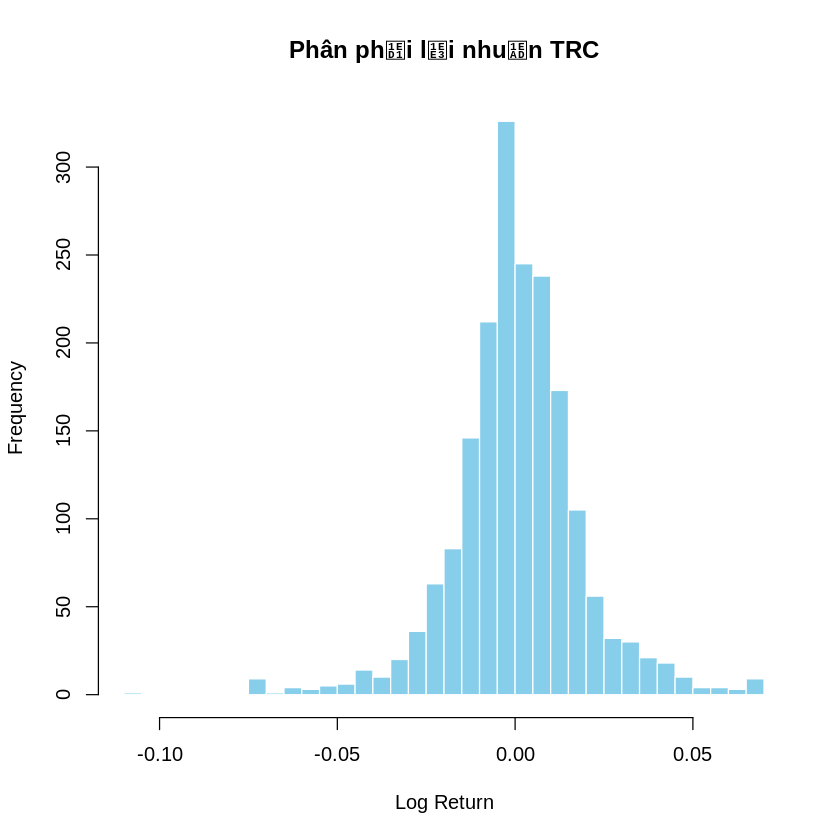

In [17]:
#Câu 2 – Phân tích danh mục 5 cổ phiếu
# (A) Data & Return
# •Tính log return
# •Thống kê cho từng cổ phiếu:
# o Mean, SD, variance
# o Skewness, kurtosis
# o Vẽ histogram của return
# Nhận xét về tính chuẩn của phân phối return

prices <- merge(
  Cl(FPT),
  Cl(TRC),
  Cl(GVR),
  Cl(MBB),
  Cl(SSI)
)

colnames(prices) <- c("TRC","FPT","GVR","MBB","SSI")
R_all <- na.omit(diff(log(prices)))

mu <- colMeans(R_all)
sd_v <- apply(R_all, 2, sd)
var_v <- apply(R_all, 2, var)
skew_v <- apply(R_all, 2, function(x){
  m <- mean(x)
  s <- sd(x)
  mean((x-m)^3)/(s^3)
})
ex_kurt_v <- apply(R_all, 2, function(x){
  m <- mean(x)
  s <- sd(x)
  mean((x-m)^4)/(s^4) - 3
})

stats_table <- data.frame(
  Mean=mu,
  SD=sd_v,
  Variance=var_v,
  Skewness=skew_v,
  Excess_Kurtosis=ex_kurt_v
)

hist(
  R_all[, "TRC"],
  breaks=50,
  main="Phân phối lợi nhuận TRC",
  col="skyblue",
  xlab="Log Return",
  border="white"
)
cat("===== stats_table=====\n")
stats_table

#(B) Lý thuyết danh mục (Markowitz)
# 1. Tính:
# o Expected return vector 𝐸(𝑅)
# o Covariance matrix Σ
# o Correlation matrix

ER_vector <- mu
Sigma <- cov(R_all)
Corr_mat <- cor(R_all)

cat("===== ER_vector=====\n")
print(ER_vector)
cat("===== Sigma=====\n")
print(Sigma)
cat("===== Corr_mat=====\n")
print(Corr_mat)

# 2. Chọn 2 cổ phiếu trong đó. Xây dựng danh mục:
# o Portfolio với tỷ trọng bằng nhau
# o Tìm tỷ trọng đầu tư để có Minimum Variance Portfolio (MVP)


v1 <- Sigma["TRC","TRC"]
v2 <- Sigma["MBB","MBB"]
c12 <- Sigma["TRC","MBB"]

cat("===== Tìm tỷ trọng đầu tư để có Minimum Variance Portfolio (MVP) =====\n")
w_fpt_mvp <- (v2-c12)/(v1+v2-2*c12)
w_trc_mvp <- 1-w_fpt_mvp
w_fpt_mvp
w_trc_mvp
# 3. Với tỷ trọng bằng nhau, hãy tính lợi nhuận kỳ vọng và rủi ro (sigma) cho danh mục gồm 5 cổ phiếu trên.

w5 <- rep(0.2, 5)

ERP5 <- sum(w5*mu)

SDP5 <- sqrt(
  as.numeric(
    t(w5)%*%Sigma%*%w5
  )
)
cat("===== ERP5 SDP5=====\n")
print(ERP5)
print(SDP5)
# 4. Liên hệ thực tiễn và nhận xét về kết quả.

Alpha (regression method):
  TRC   FPT   GVR   MBB   SSI 
6e-04 6e-04 4e-04 4e-04 2e-04 

Beta (regression method):
   TRC    FPT    GVR    MBB    SSI 
0.8370 0.5118 1.1808 1.1363 1.3557 

Beta (cov/var method, for comparison):
   TRC    FPT    GVR    MBB    SSI 
0.8370 0.5118 1.1808 1.1363 1.3557 

CAPM Expected Return (using regression beta):
   TRC    FPT    GVR    MBB    SSI 
0.0490 0.0402 0.0582 0.0570 0.0629 

Comparison: Realized vs CAPM Return
      Real   CAPM
TRC 0.2097 0.0490
FPT 0.1791 0.0402
GVR 0.1687 0.0582
MBB 0.1577 0.0570
SSI 0.1091 0.0629


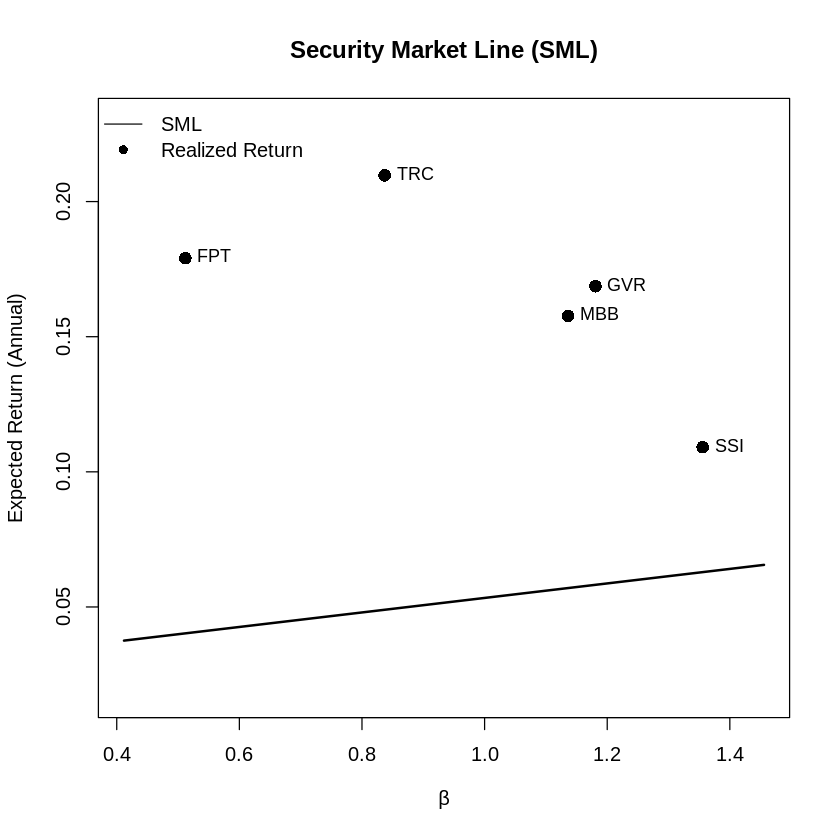

In [12]:
# ==========================================
# --- 1. Risk Free Rate ---
rf_annual <- 0.02649
rf_daily <- rf_annual / 250

# --- 2. Market Return ---
Rm <- na.omit(diff(log(Cl(VNINDEX))))

# --- 3. Excess Returns ---
Ri_excess <- R_all - rf_daily
Rm_excess <- Rm - rf_daily

# ==========================================
# 4. Estimate Beta + Alpha for Each Stock
# ==========================================
# Original regression method
beta_lm <- apply(Ri_excess, 2, function(x) coef(lm(x ~ Rm_excess))[2])
alpha_lm <- apply(Ri_excess, 2, function(x) coef(lm(x ~ Rm_excess))[1])

cat("Alpha (regression method):\n")
print(round(alpha_lm, 4))
cat("\nBeta (regression method):\n")
print(round(beta_lm, 4))

# Covariance/variance method (for comparison)
beta2 <- apply(Ri_excess, 2, function(x) cov(x, Rm_excess) / var(Rm_excess))

cat("\nBeta (cov/var method, for comparison):\n")
print(round(beta2, 4))

# ==========================================
# 5. CAPM Expected Return (using regression beta)
# ==========================================
ERm <- mean(as.numeric(Rm)) * 250
ERP <- ERm - rf_annual
ER_capm <- rf_annual + beta_lm * ERP

cat("\nCAPM Expected Return (using regression beta):\n")
print(round(ER_capm, 4))

# ==========================================
# 6. Realized Return Comparison
# ==========================================
ER_real <- colMeans(R_all) * 250

cat("\nComparison: Realized vs CAPM Return\n")
print(round(cbind(Real = ER_real, CAPM = ER_capm), 4))

# ==========================================
# 7. Prepare Plot Data
# ==========================================
assets <- colnames(R_all)
beta_all <- as.numeric(beta_lm)  # still using regression beta for plot
ER_real_all <- as.numeric(ER_real)

# ==========================================
# 8. SML Line Coordinates
# ==========================================
x_line <- seq(min(beta_all) - 0.1, max(beta_all) + 0.1, length.out = 200)
y_line <- rf_annual + x_line * ERP

# ==========================================
# 9. Plot Security Market Line
# ==========================================
plot(
  x_line,
  y_line,
  type = "l",
  lwd = 2,
  xlim = range(beta_all) + c(-0.1, 0.1),
  ylim = range(c(ER_real_all, y_line)) + c(-0.02, 0.02),
  xlab = expression(beta),
  ylab = "Expected Return (Annual)",
  main = "Security Market Line (SML)"
)

# Plot Realized Return Points
points(beta_all, ER_real_all, pch = 16, cex = 1.4)

# Labels
text(beta_all, ER_real_all, labels = assets, pos = 4, cex = 0.9)

# Legend
legend(
  "topleft",
  legend = c("SML", "Realized Return"),
  lty = c(1, NA),
  pch = c(NA, 16),
  bty = "n"
)

In [14]:
# ==========================================
# FULL OUTPUT BLOCK (REORDERED)
# ==========================================

# ===== 1. MARKET INFO =====
ERm <- mean(as.numeric(Rm)) * 250
ERP <- ERm - rf_annual
cat("===== 1. MARKET INFO =====\n")
cat("ERm (Market Return):", round(ERm,4), "\n")
cat("ERP (Market Risk Premium):", round(ERP,4), "\n\n")

# ===== 2. DESCRIPTIVE STATISTICS =====
cat("===== 2. DESCRIPTIVE STATISTICS =====\n")
print(stats_table)
cat("\n")

# ===== 3. MVP (TRC & SSI) =====
cat("===== 3. MVP (TRC & SSI) =====\n")
cat("Weight TRC:", round(w_trc_mvp,4), "\n")
cat("Weight SSI:", round(w_fpt_mvp,4), "\n\n")

# ===== 4. BETA (Covariance Method) =====
cat("\nBeta (cov/var method, for comparison):\n")
print(round(beta2, 4))
cat("\n")

# ===== 5. BETA (Regression) =====
cat("===== 5. BETA (Regression) =====\n")
print(round(beta_all,4))
cat("\n")

# ===== 6. REGRESSION SUMMARY (First Stock) =====
cat("===== 6. REGRESSION SUMMARY (First Stock) =====\n")
print(summary(lm(Ri_excess[,1] ~ Rm_excess)))
cat("\n")

# ===== 7. ALPHA & BETA TABLE =====
cat("===== 7. ALPHA & BETA =====\n")
print(round(cbind(alpha = alpha_lm, beta = beta_lm), 4))
cat("\n")

# ===== 8. ALPHA SIGNIFICANCE TEST =====
alpha_test <- lapply(colnames(Ri_excess), function(stock){
  model <- lm(Ri_excess[,stock] ~ Rm_excess)
  coef(summary(model))[1,]   # intercept only
})
alpha_test <- do.call(rbind, alpha_test)
rownames(alpha_test) <- colnames(Ri_excess)
cat("===== 8. ALPHA SIGNIFICANCE =====\n")
print(round(alpha_test, 4))
cat("\n")

# ===== 9. REALIZED vs CAPM & MISPRICING =====
mispricing <- ER_real - ER_capm
cat("===== 9. REALIZED vs CAPM & MISPRICING =====\n")
print(round(cbind(
  Real = ER_real,
  CAPM = ER_capm,
  Mispricing = mispricing
), 4))
cat("\n")

# ===== 10. COVARIANCE MATRIX =====
cat("===== 10. COVARIANCE MATRIX =====\n")
print(Sigma)
cat("\n")

# ===== 11. CORRELATION MATRIX =====
cat("===== 11. CORRELATION MATRIX =====\n")
print(cor(R_all))
cat("\n")

# ===== 12. R-SQUARED =====
R2_all <- sapply(colnames(Ri_excess), function(stock){
  summary(lm(Ri_excess[,stock] ~ Rm_excess))$r.squared
})
cat("===== 12. R-SQUARED =====\n")
print(round(R2_all, 4))
cat("\n")

# ===== 13. SHARPE RATIO =====
sharpe_ratio <- (ER_real - rf_annual) / (sd_v * sqrt(250))
cat("===== 13. SHARPE RATIO =====\n")
print(round(sharpe_ratio, 4))
cat("\n")

# ===== 14. EXPECTED RETURN VECTOR =====
cat("===== 14. EXPECTED RETURN VECTOR =====\n")
print(ER_vector)
cat("\n")

# ===== 15. PORTFOLIO (EQUAL WEIGHT) =====
cat("===== 15. PORTFOLIO (EQUAL WEIGHT) =====\n")
cat("Expected Return:", round(ERP5,4), "\n")
cat("Risk (Std Dev):", round(SDP5,4), "\n\n")

# ===== 16. DIVERSIFICATION =====
avg_sd <- mean(sd_v * sqrt(250))
portfolio_sd <- SDP5 * sqrt(250)
cat("===== 16. DIVERSIFICATION =====\n")
cat("Average Individual Risk:", round(avg_sd,4), "\n")
cat("Portfolio Risk:", round(portfolio_sd,4), "\n\n")

===== 1. MARKET INFO =====
ERm (Market Return): 0.0533 
ERP (Market Risk Premium): 0.0269 

===== 2. DESCRIPTIVE STATISTICS =====
            Mean         SD     Variance    Skewness Excess_Kurtosis
TRC 0.0008387757 0.01797238 0.0003230063 -0.21627673        3.240219
FPT 0.0007162905 0.02330402 0.0005430774 -0.09487858        1.427743
GVR 0.0006747101 0.03058034 0.0009351573 -0.11641775        1.356843
MBB 0.0006308073 0.02086612 0.0004353948 -0.91792341        7.889562
SSI 0.0004365056 0.02652938 0.0007038079 -0.30427919        2.599056

===== 3. MVP (TRC & SSI) =====
Weight TRC: 0.3386 
Weight SSI: 0.6614 


Beta (cov/var method, for comparison):
   TRC    FPT    GVR    MBB    SSI 
0.8370 0.5118 1.1808 1.1363 1.3557 

===== 5. BETA (Regression) =====
[1] 0.8370 0.5118 1.1808 1.1363 1.3557

===== 6. REGRESSION SUMMARY (First Stock) =====

Call:
lm(formula = Ri_excess[, 1] ~ Rm_excess)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.059385 -0.008413 -0.000688  0.00685

In [15]:
library(quantmod)
library(TTR)

# ============================
# Define the timeframe (last 6 months)
# ============================
end_date <- Sys.Date()
start_date <- end_date - 180  # approx 6 months

# Assuming TRC is already loaded (multi-year)
TRC_recent <- window(TRC, start=start_date, end=end_date)

# ============================
# Calculate log returns (optional)
# ============================
trc_return <- na.omit(diff(log(Cl(TRC_recent))))


# ============================
# Extract indicator values for analysis
# ============================

# Moving Averages
SMA5 <- SMA(Cl(TRC_recent), n=5)
SMA20 <- SMA(Cl(TRC_recent), n=20)

# MACD
macd <- MACD(Cl(TRC_recent), nFast=12, nSlow=26, nSig=9)
macd_line <- macd$macd
signal_line <- macd$signal
histogram <- macd$macd - macd$signal

# Bollinger Bands
bb <- BBands(Cl(TRC_recent), n=20, sd=2)
upper_band <- bb$up
lower_band <- bb$dn
middle_band <- bb$mavg

# RSI
rsi <- RSI(Cl(TRC_recent), n=14)

# ============================
# Latest indicator snapshot
# ============================
latest <- data.frame(
  Date = index(TRC_recent)[NROW(TRC_recent)],
  Close = as.numeric(Cl(TRC_recent)[NROW(TRC_recent)]),
  SMA5 = as.numeric(SMA5[NROW(SMA5)]),
  SMA20 = as.numeric(SMA20[NROW(SMA20)]),
  MACD = as.numeric(macd_line[NROW(macd_line)]),
  Signal = as.numeric(signal_line[NROW(signal_line)]),
  MACD_Hist = as.numeric(histogram[NROW(histogram)]),
  Upper_BB = as.numeric(upper_band[NROW(upper_band)]),
  Middle_BB = as.numeric(middle_band[NROW(middle_band)]),
  Lower_BB = as.numeric(lower_band[NROW(lower_band)]),
  RSI = as.numeric(rsi[NROW(rsi)])
)

print("===== Latest Technical Indicators (6-Month Window) =====")
print(latest)

# ============================
# Quick Interpretation
# ============================
latest$SMA_Trend <- ifelse(latest$SMA5 > latest$SMA20, "Bullish", "Bearish")
latest$RSI_Signal <- ifelse(latest$RSI > 70, "Overbought",
                            ifelse(latest$RSI < 30, "Oversold", "Neutral"))
latest$Price_vs_BB <- ifelse(latest$Close > latest$Upper_BB, "Above Upper BB",
                             ifelse(latest$Close < latest$Lower_BB, "Below Lower BB", "Within BB"))

print("===== Quick Signal Interpretation (6-Month Window) =====")
print(latest[, c("SMA_Trend", "RSI_Signal", "Price_vs_BB")])

[1] "===== Latest Technical Indicators (6-Month Window) ====="
        Date Close  SMA5  SMA20       MACD    Signal MACD_Hist Upper_BB
1 2026-04-10  72.6 71.64 71.245 -0.9751325 -1.483214 0.5080812 74.24265
  Middle_BB Lower_BB      RSI
1    71.245 68.24735 50.43606
[1] "===== Quick Signal Interpretation (6-Month Window) ====="
  SMA_Trend RSI_Signal Price_vs_BB
1   Bullish    Neutral   Within BB
